In [1]:
import pandas as pd
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt


In [2]:
#Define QID - question matching
qids = ["V201324","V201416", "V202234", "V202257", "V202287", "V202332", "V202337", "V202348", "V202371", "V202378"]
name_dict = {"V201324" : "Current Economy", "V201416" : "Gay Marriage", "V202234" : "Refugee Allowing", 
            "V202257" : "Income Inequality", "V202287" : "Gender Role", "V202332": "Climate Change",
            "V202337": "Gun Regulation", "V202348": "Drug Addiction", "V202371": "Race Diversity", "V202378": "Health Insurance"}

def get_counts(path, qids): #function to get a dict with counts for each question

    value_list = []

    for id in qids:
        df = pd.read_csv(path + id + ".csv")
        df['Response'] = pd.to_numeric(df['Response'], errors='coerce') 

        value_counts = Counter(df['Response'].dropna())

        if id in ["V201324", "V202332"]:

            answers = {i: value_counts[i] for i in range(1, 6)}
        else:
            answers = {i: value_counts[i] for i in range(1, 4)}

        value_list.append({name_dict[id]: answers})

    return value_list


In [3]:
def get_human_counts(path, qids): #getting results from anes 2020

     anes_df = pd.read_csv(path)

     human_values = []

     for id in qids:

          human_counts = Counter(anes_df[id].dropna())

          if id in ["V201324", "V202332"]:

               answers = {i: human_counts[i] for i in range(1, 6)}
          else:
               answers = {i: human_counts[i] for i in range(1, 4)}

          human_values.append({name_dict[id]: answers})

     return human_values

human_results = get_human_counts("data/2020 ANES_test.csv", qids)

/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_22151/4095551727.py:3: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  anes_df = pd.read_csv(path)


In [4]:
from scipy.stats import entropy  # entropy is a function to compute KL-divergence

def kl_divergence_between_sets(set1, set2):

    kl_results = {}

    dict1 = {list(d.keys())[0]: list(d.values())[0] for d in set1}
    dict2 = {list(d.keys())[0]: list(d.values())[0] for d in set2}

    for question in dict1.keys():
        if question not in dict2:
            continue  

        p_counts = dict1[question]
        q_counts = dict2[question]

        p = np.array([p_counts.get(k, 0) for k in p_counts], dtype=float)
        q = np.array([q_counts.get(k, 0) for k in p_counts], dtype=float)

        p /= p.sum()
        q /= q.sum()

        epsilon = 1e-10
        p = np.clip(p, epsilon, 1)
        q = np.clip(q, epsilon, 1)
        
        kl_pq = entropy(p, q) 
        kl_results[question] = kl_pq

    return kl_results

In [5]:
#JSD divergence is a more numerically stable version of KL-divergence - better for our case
def jsd_divergence_between_sets(set1, set2, base=2):

    jsd_results = {}

    dict1 = {list(d.keys())[0]: list(d.values())[0] for d in set1}
    dict2 = {list(d.keys())[0]: list(d.values())[0] for d in set2}

    for question in dict1.keys():
        if question not in dict2:
            continue 

        p_counts = dict1[question]
        q_counts = dict2[question]

        p = np.array([p_counts.get(k, 0) for k in p_counts], dtype=float)
        q = np.array([q_counts.get(k, 0) for k in p_counts], dtype=float)

        p /= p.sum()
        q /= q.sum()

        epsilon = 1e-10
        p = np.clip(p, epsilon, 1)
        q = np.clip(q, epsilon, 1)

        m = 0.5 * (p + q)
        jsd_pq = 0.5 * (entropy(p, m, base=base) + entropy(q, m, base=base)) 
        jsd_results[question] = jsd_pq

    return jsd_results


In [6]:
def jsd_divergence_for_bootstrapping(human_sample, bootstrap_sample, base=2): #JSD function to be used in boostrapping

    p_counts = human_sample
    q_counts = bootstrap_sample

    p = np.array([p_counts.get(k, 0) for k in p_counts], dtype=float)
    q = np.array([q_counts.get(k, 0) for k in p_counts], dtype=float)

    p /= p.sum()
    q /= q.sum()

    epsilon = 1e-10
    p = np.clip(p, epsilon, 1)
    q = np.clip(q, epsilon, 1)

    m = 0.5 * (p + q)
    jsd_pq = 0.5 * (entropy(p, m, base=base) + entropy(q, m, base=base))

    return jsd_pq


In [17]:
human_df = pd.read_csv("data/2020 ANES_test.csv") 

def bootstrap_jsd(path, qid, n_boot=2000, base=2):

    question_df = pd.read_csv(path + qid + ".csv")
    question_df['Response'] = pd.to_numeric(question_df['Response'], errors='coerce')

    responses = np.array(question_df['Response'].dropna())

    human_responses = {list(d.keys())[0]: list(d.values())[0] for d in human_results}[name_dict[qid]]

    jsd_samples = []

    for _ in range(n_boot):
        sample = np.random.choice(responses, size=len(responses), replace=True) #sample with replacement
        
        counts = Counter(sample)

        jsd_val = jsd_divergence_for_bootstrapping(human_responses, counts, base=base) #compute JSD for this iteration
        jsd_samples.append(jsd_val) #append to the samples list

    jsd_samples = np.array(jsd_samples)
    mean_jsd = jsd_samples.mean()
    ci_lower, ci_upper = np.percentile(jsd_samples, [2.5, 97.5])
    
    return (("mean", mean_jsd), ("ci_lower", ci_lower), ("ci_upper", ci_upper))


/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_21197/1295843025.py:1: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  human_df = pd.read_csv("data/2020 ANES_test.csv")


In [ ]:
#Create CIs and compare them
ci_replicate = []
ci_reformulated = []

for qid in qids:
    ci_replicate.append((name_dict[qid], bootstrap_jsd(path = "MLLM Results/main_mq_results/full_results_2020_", qid = qid)))
    ci_reformulated.append((name_dict[qid], bootstrap_jsd(path = "MLLM Results/main_mq_reform_3rdP_results/full_results_2020_", qid = qid)))

ci_replicate = [{item[0] : item[1]} for item in ci_replicate]
ci_reformulated = [{item[0] : item[1]} for item in ci_reformulated]

ci_replicate = {list(d.keys())[0]: list(d.values())[0] for d in ci_replicate}
ci_reformulated = {list(d.keys())[0]: list(d.values())[0] for d in ci_reformulated}

ci_comparison = {key: (ci_replicate[key], ci_reformulated[key]) for key in ci_replicate.keys()}

In [ ]:
# ci_comparison['Current Economy']

((('mean', np.float64(0.30898472712380126)),
  ('ci_lower', np.float64(0.304093903296033)),
  ('ci_upper', np.float64(0.3138935169470861))),
 (('mean', np.float64(0.1202372632647284)),
  ('ci_lower', np.float64(0.11725218508352624)),
  ('ci_upper', np.float64(0.1234986434950094))))

In [ ]:
def plot_replicate_stacked(human_results, silicon_results, jsd_results1, jsd_results2,
          model1='GPT-3.5-turbo', model2='GPT-4.1', output_path=''):

    categories = [
        'Climate Change', 'Current Economy', 'Refugee Allowing', 'Health Insurance',
        'Income Inequality', 'Race Diversity', 'Drug Addiction',
        'Gay Marriage', 'Gun Regulation', 'Gender Role'
    ]

    x = np.arange(len(categories))

    # Extract dictionaries
    human_dict = {list(d.keys())[0]: list(d.values())[0] for d in human_results}
    silicon_dict = {list(d.keys())[0]: list(d.values())[0] for d in silicon_results}

    human_stack = []
    silicon_stack = []
    jsd1 = []
    jsd2 = []

    # --- Build stacked distributions for each category ---
    for question in categories:
        h_dist = np.array(list(human_dict[question].values()), dtype=float)
        s_dist = np.array(list(silicon_dict[question].values()), dtype=float)

        h_dist /= h_dist.sum()
        s_dist /= s_dist.sum()

        human_stack.append(h_dist)
        silicon_stack.append(s_dist)

        jsd1.append(jsd_results1[question])
        jsd2.append(jsd_results2[question])

    # --- Colors (same as original but consistent) ---
    human_colors = [
        (0.12, 0.47, 0.71, 1.0),
        (0.20, 0.63, 0.17, 1.0),
        (0.96, 0.73, 0.07, 1.0),
        (1.0, 0.50, 0.0, 1.0),
        (0.78, 0.24, 0.24, 1.0),
    ]

    silicon_colors = [
        (0.12, 0.47, 0.71, 0.45),
        (0.20, 0.63, 0.17, 0.45),
        (0.96, 0.73, 0.07, 0.45),
        (1.0, 0.50, 0.0, 0.45),
        (0.78, 0.24, 0.24, 0.45),
    ]

    fig, ax1 = plt.subplots(figsize=(7, 4.5))
    bar_width = 0.33

    # --- Plot stacked Human bars ---
    for idx, dist in enumerate(human_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] - bar_width/2,
                val,
                width=bar_width,
                bottom=bottom,
                color=human_colors[i],
                label='Human (Darker colors)' if (idx == 0 and i == 0) else ""
            )
            bottom += val

    # --- Plot stacked Silicon bars ---
    for idx, dist in enumerate(silicon_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] + bar_width/2,
                val,
                width=bar_width,
                bottom=bottom,
                color=silicon_colors[i],
                label='Silicon (Lighter colors)' if (idx == 0 and i == 0) else ""
            )
            bottom += val

    # --- Axes ---
    ax1.set_ylabel('Response rate')
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories, rotation=30, ha='center')
    ax1.set_ylim(0, 1.)
    ax1.set_xmargin(0.00)

    ax1.set_xlabel('')
    ax1.legend(loc='upper left', ncol=1, frameon=True, bbox_to_anchor=(0, 1.22))

    # --- JSD lines on secondary axis ---
    ax2 = ax1.twinx()
    ax2.plot(
        x, jsd1,
        color='black', marker='D', markerfacecolor='none',
        markersize=9, linewidth=2, markeredgewidth=2,linestyle='--',
        label=f'JS-divergence {model1}'
    )
    ax2.plot(
        x, jsd2,
        color='red', marker='D', markerfacecolor='none',
        markersize=9, linewidth=2,markeredgewidth=2,
        label=f'JS-divergence {model2}'
    )

    ax2.set_ylabel('JS-divergence')
    ax2.set_ylim(0, 0.5)
    ax2.set_xmargin(0.00)

    # --- JSD legend ---
    ax2.legend(loc='upper right', frameon=True, bbox_to_anchor=(1, 1.22))
    plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
    # --- Remove figure box / spines ---
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)   # optional
    ax1.spines['left'].set_visible(False)     # optional

    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)   # optional
    ax2.spines['left'].set_visible(False)     # optional

    # ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
    fig.tight_layout()

    # ----- Save figure as compact PDF -----
    if output_path != '':
        fig.savefig(
            output_path,
            format="pdf",
            bbox_inches="tight",     # removes extra margins
            pad_inches=0.05,         # small padding
            dpi=300                  # high quality
        )
        print(f"Saved figure to {output_path}")
# plot_replicate_stacked(human_results, replicate_results, jsd_results_original, jsd_results_replicate, 'GPT-3.5-turbo', 'GPT-4.1', 'plots/replicate-gpt4.1.pdf')


In [8]:
# GPT-4.1
original_results = get_counts("results/main_mq_results_unzipped/full_results_2020_", qids)
replicate_results = get_counts("Publication Results/GPT4.1/main_mq_results/full_results_2020_", qids)
reformulated_results = get_counts("Publication Results/GPT4.1/main_mq_reform_results/full_results_2020_", qids)
priming_results = get_counts("Publication Results/GPT4.1/main_mq_priming_results/full_results_2020_", qids)
preamble_results = get_counts("Publication Results/GPT4.1/main_mq_preamble_results/full_results_2020_", qids)


jsd_results_original = jsd_divergence_between_sets(human_results, original_results, base=2)
jsd_results_replicate = jsd_divergence_between_sets(human_results, replicate_results, base=2)
jsd_results_reformulated = jsd_divergence_between_sets(human_results, reformulated_results, base=2)
jsd_results_priming = jsd_divergence_between_sets(human_results, priming_results, base = 2)
jsd_results_preamble = jsd_divergence_between_sets(human_results, preamble_results, base = 2)

diff_reformulated_vs_replicate = {key: (jsd_results_reformulated[key] - jsd_results_replicate[key]) for key in jsd_results_replicate.keys()}
diff_preamble_vs_replicate = {key: (jsd_results_preamble[key] - jsd_results_replicate[key]) for key in jsd_results_replicate.keys()}
diff_priming_vs_replicate = {key: (jsd_results_priming[key] - jsd_results_replicate[key]) for key in jsd_results_replicate.keys()}

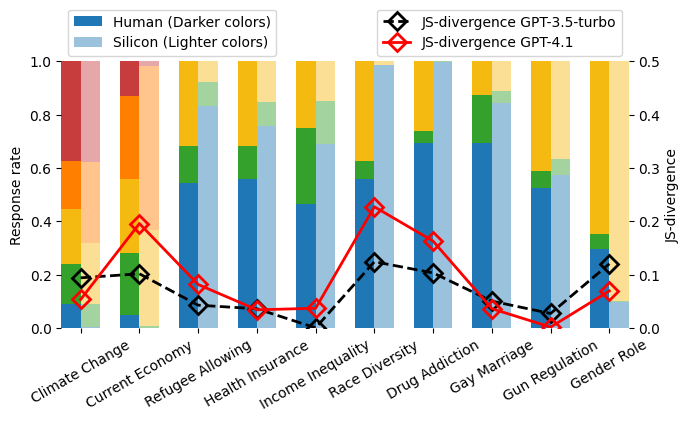

In [9]:
# GPT-4.1
plot_replicate_stacked(human_results, replicate_results, jsd_results_original, jsd_results_replicate, 
                       'GPT-3.5-turbo', 'GPT-4.1', '')


In [ ]:
def plot_replicate_w_condition_stacked(silicon_results_1, silicon_results_2, jsd_results1, jsd_results2, label1, label2, output_path=''):
    categories = [
        'Climate Change', 'Current Economy', 'Refugee Allowing', 'Health Insurance',
        'Income Inequality', 'Race Diversity', 'Drug Addiction',
        'Gay Marriage', 'Gun Regulation', 'Gender Role'
    ]

    x = np.arange(len(categories))

    silicon_dict1 = {list(d.keys())[0]: list(d.values())[0] for d in silicon_results_1}
    silicon_dict2 = {list(d.keys())[0]: list(d.values())[0] for d in silicon_results_2}
 
    # Define colors
    silicon_colors_1 = ['#4A90E2', '#D0021B', '#7ED321', '#F5A623', '#9013FE']
    silicon_colors_2 = ['#A4C8F0', '#F58F8F', '#B8E986', '#F8E79C', '#C9A2F7'] 

    silicon_colors_1 = [
    (0.12, 0.47, 0.71, 1.0), # Strongest (Dark Blue)
    (0.40, 0.65, 0.82, 1.0), # Medium Blue
    (0.5, 0.5, 0.5, 1.0),    # Neutral (Gray)
    (0.84, 0.35, 0.35, 1.0), # Medium Red
    (0.78, 0.24, 0.24, 1.0)  # Weakest (Dark Red)
]
    silicon_colors_2 = [
    (0.12, 0.47, 0.71, 0.5), # Transparent Blue
    (0.40, 0.65, 0.82, 0.5), # Transparent Medium Blue
    (0.5, 0.5, 0.5, 0.5),    # Transparent Gray
    (0.84, 0.35, 0.35, 0.5), # Transparent Medium Red
    (0.78, 0.24, 0.24, 0.5)  # Transparent Red
]
    
#     silicon_colors_1 = [
#     (0.12, 0.47, 0.71, 1.0), # Strongest (Blue)
#     (0.20, 0.63, 0.17, 1.0), # Medium-Strong (Green)
#     (0.96, 0.73, 0.07, 1.0), # Neutral (Yellow/Gold)
#     (1.0, 0.50, 0.0, 1.0),   # Medium-Weak (Orange)
#     (0.78, 0.24, 0.24, 1.0)  # Weakest (Red)
# ]
#     silicon_colors_2 = [
#     (0.12, 0.47, 0.71, 0.5), # Transparent Blue
#     (0.20, 0.63, 0.17, 0.5), # Transparent Green
#     (0.96, 0.73, 0.07, 0.5), # Transparent Yellow/Gold
#     (1.0, 0.50, 0.0, 0.5),   # Transparent Orange
#     (0.78, 0.24, 0.24, 0.5)  # Transparent Red
# ]

    silicon1_stack = []
    silicon2_stack = []
    jsd1 = []
    jsd2 = []

    # --- Build stacked distributions for each category ---
    for question in categories:
        h_dist = np.array(list(silicon_dict1[question].values()), dtype=float)
        s_dist = np.array(list(silicon_dict2[question].values()), dtype=float)

        h_dist /= h_dist.sum()
        s_dist /= s_dist.sum()

        silicon1_stack.append(h_dist)
        silicon2_stack.append(s_dist)

        jsd1.append(jsd_results1[question])
        jsd2.append(jsd_results2[question])

    # --- Colors (same as original but consistent) ---
    silicon_colors_1 = [
        (0.12, 0.47, 0.71, 1.0),
        (0.20, 0.63, 0.17, 1.0),
        (0.96, 0.73, 0.07, 1.0),
        (1.0, 0.50, 0.0, 1.0),
        (0.78, 0.24, 0.24, 1.0),
    ]

    silicon_colors_2 = [
        (0.12, 0.47, 0.71, 0.45),
        (0.20, 0.63, 0.17, 0.45),
        (0.96, 0.73, 0.07, 0.45),
        (1.0, 0.50, 0.0, 0.45),
        (0.78, 0.24, 0.24, 0.45),
    ]

    fig, ax1 = plt.subplots(figsize=(7, 4.5))
    bar_width = 0.33

    # --- Plot stacked Human bars ---
    for idx, dist in enumerate(silicon1_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] - bar_width/2,
                val,
                width=bar_width,
                bottom=bottom,
                color=silicon_colors_1[i],
                label=label1+' (Darker colors)' if (idx == 0 and i == 0) else ""
            )
            bottom += val

    # --- Plot stacked Silicon bars ---
    for idx, dist in enumerate(silicon2_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] + bar_width/2,
                val,
                width=bar_width,
                bottom=bottom,
                color=silicon_colors_2[i],
                label=label2+' (Lighter colors)' if (idx == 0 and i == 0) else ""
            )
            bottom += val

    # --- Axes ---
    ax1.set_ylabel('Response rate')
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories, rotation=30, ha='center')
    ax1.set_ylim(0, 1.)
    ax1.set_xmargin(0.00)

    ax1.set_xlabel('')
    ax1.legend(loc='upper left', ncol=1, frameon=True, bbox_to_anchor=(0, 1.22))

    # --- JSD lines on secondary axis ---
    ax2 = ax1.twinx()
    ax2.plot(
        x, jsd1,
        color='black', marker='D', markerfacecolor='none',
        markersize=9, linewidth=2, markeredgewidth=2,linestyle='-',
        label=f'JS-divergence {label1}'
    )
    ax2.plot(
        x, jsd2,
        color='red', marker='D', markerfacecolor='none',
        markersize=9, linewidth=2,markeredgewidth=2,
        label=f'JS-divergence {label2}'
    )

    ax2.set_ylabel('JS-divergence')
    ax2.set_ylim(0, 0.5)
    ax2.set_xmargin(0.00)

    # --- JSD legend ---
    ax2.legend(loc='upper right', frameon=True, bbox_to_anchor=(1, 1.22))
    plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
    # --- Remove figure box / spines ---
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)   # optional
    ax1.spines['left'].set_visible(False)     # optional

    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)   # optional
    ax2.spines['left'].set_visible(False)     # optional

    # ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
    fig.tight_layout()

    # ----- Save figure as compact PDF -----
    if output_path != '':
        fig.savefig(
            output_path,
            format="pdf",
            bbox_inches="tight",     # removes extra margins
            pad_inches=0.05,         # small padding
            dpi=300                  # high quality
        )
        print(f"Saved figure to {output_path}")

Saved figure to plots/gpt4.1-reformulated.pdf


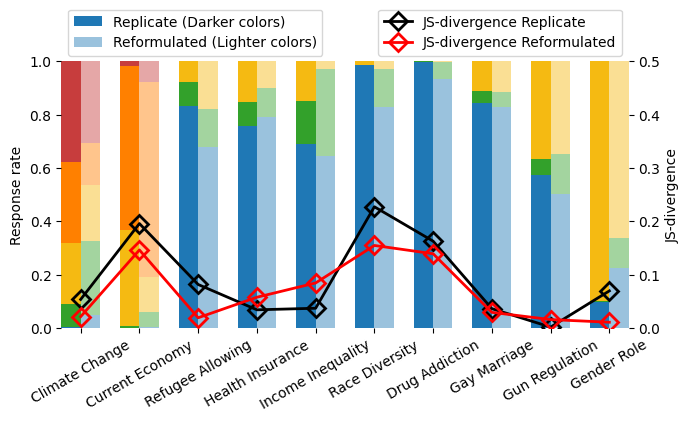

In [ ]:
plot_replicate_w_condition_stacked(replicate_results, reformulated_results, jsd_results_replicate, jsd_results_reformulated, 
              'Replicate', 'Reformulated','plots/gpt4.1-reformulated.pdf')

Saved figure to plots/gpt4.1-priming.pdf


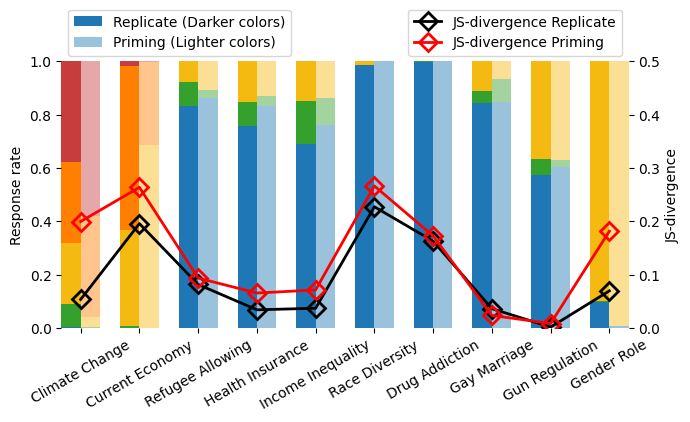

In [ ]:
plot_replicate_w_condition_stacked(replicate_results, priming_results, jsd_results_replicate, jsd_results_priming, 
              'Replicate', 'Priming','plots/gpt4.1-priming.pdf')

Saved figure to plots/gpt4.1-preamble.pdf


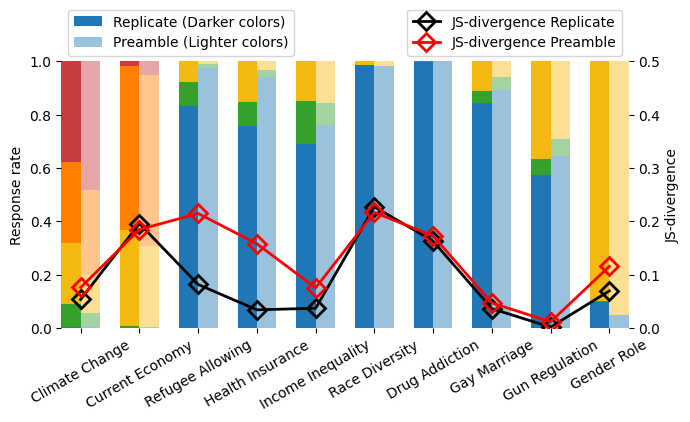

In [ ]:
plot_replicate_w_condition_stacked(replicate_results, preamble_results, jsd_results_replicate, jsd_results_preamble, 
              'Replicate', 'Preamble','plots/gpt4.1-preamble.pdf')

In [10]:
# LLama 3.1 8b
original_results = get_counts("results/main_mq_results_unzipped/full_results_2020_", qids)
replicate_results = get_counts("MLLM Results/main_mq_results/full_results_2020_", qids)
reformulated_results = get_counts("MLLM Results/main_mq_reform_3rdP_results/full_results_2020_", qids)
priming_results = get_counts("MLLM Results/Priming/Original/full_results_2020_", qids)
preamble_results = get_counts("MLLM Results/Preamble/Original/full_results_2020_", qids)


jsd_results_original = jsd_divergence_between_sets(human_results, original_results, base=2)
jsd_results_replicate = jsd_divergence_between_sets(human_results, replicate_results, base=2)
jsd_results_reformulated = jsd_divergence_between_sets(human_results, reformulated_results, base=2)
jsd_results_priming = jsd_divergence_between_sets(human_results, priming_results, base = 2)
jsd_results_preamble = jsd_divergence_between_sets(human_results, preamble_results, base = 2)

diff_reformulated_vs_replicate = {key: (jsd_results_reformulated[key] - jsd_results_replicate[key]) for key in jsd_results_replicate.keys()}
diff_preamble_vs_replicate = {key: (jsd_results_preamble[key] - jsd_results_replicate[key]) for key in jsd_results_replicate.keys()}
diff_priming_vs_replicate = {key: (jsd_results_priming[key] - jsd_results_replicate[key]) for key in jsd_results_replicate.keys()}

Saved figure to plots/replicate-llama8b.pdf


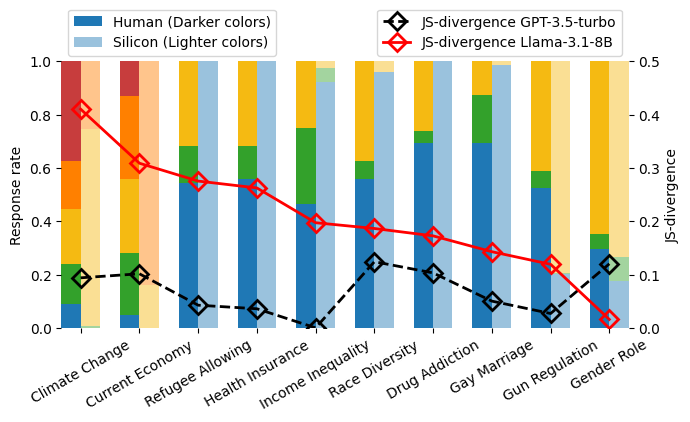

In [11]:
plot_replicate_stacked(human_results, replicate_results, jsd_results_original, jsd_results_replicate, 
                       'GPT-3.5-turbo', 'Llama-3.1-8B', 'plots/replicate-llama8b.pdf')


In [13]:
# LLama 3.1 70b
# GPT-4.1
original_results = get_counts("results/main_mq_results_unzipped/full_results_2020_", qids)
replicate_results = get_counts("Publication Results/70B-Llama/main_mq_results/full_results_2020_", qids)
reformulated_results = get_counts("Publication Results/70B-Llama/main_mq_reform_results/full_results_2020_", qids)
# priming_results = get_counts("Publication Results/70B-Llama/main_mq_priming_results/full_results_2020_", qids)
# preamble_results = get_counts("Publication Results/70B-Llama/main_mq_preamble_results/full_results_2020_", qids)


jsd_results_original = jsd_divergence_between_sets(human_results, original_results, base=2)
jsd_results_replicate = jsd_divergence_between_sets(human_results, replicate_results, base=2)
jsd_results_reformulated = jsd_divergence_between_sets(human_results, reformulated_results, base=2)
# jsd_results_priming = jsd_divergence_between_sets(human_results, priming_results, base = 2)
# jsd_results_preamble = jsd_divergence_between_sets(human_results, preamble_results, base = 2)

# diff_reformulated_vs_replicate = {key: (jsd_results_reformulated[key] - jsd_results_replicate[key]) for key in jsd_results_replicate.keys()}
# diff_preamble_vs_replicate = {key: (jsd_results_preamble[key] - jsd_results_replicate[key]) for key in jsd_results_replicate.keys()}
# diff_priming_vs_replicate = {key: (jsd_results_priming[key] - jsd_results_replicate[key]) for key in jsd_results_replicate.keys()}


Saved figure to plots/replicate-llama70b.pdf


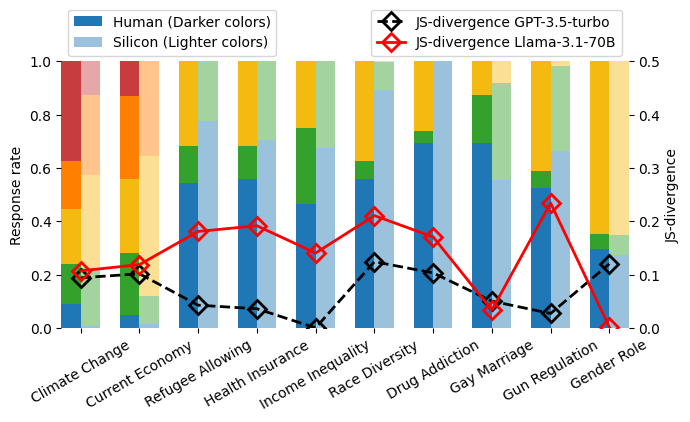

In [14]:
plot_replicate_stacked(human_results, replicate_results, jsd_results_original, jsd_results_replicate, 
                       'GPT-3.5-turbo', 'Llama-3.1-70B', 'plots/replicate-llama70b.pdf')
